## Fully Visible Sigmoid Belief Network (FVSBN)

![WhatsApp Image 2026-03-16 at 6.24.39 PM.jpeg](<attachment:WhatsApp Image 2026-03-16 at 6.24.39 PM.jpeg>)
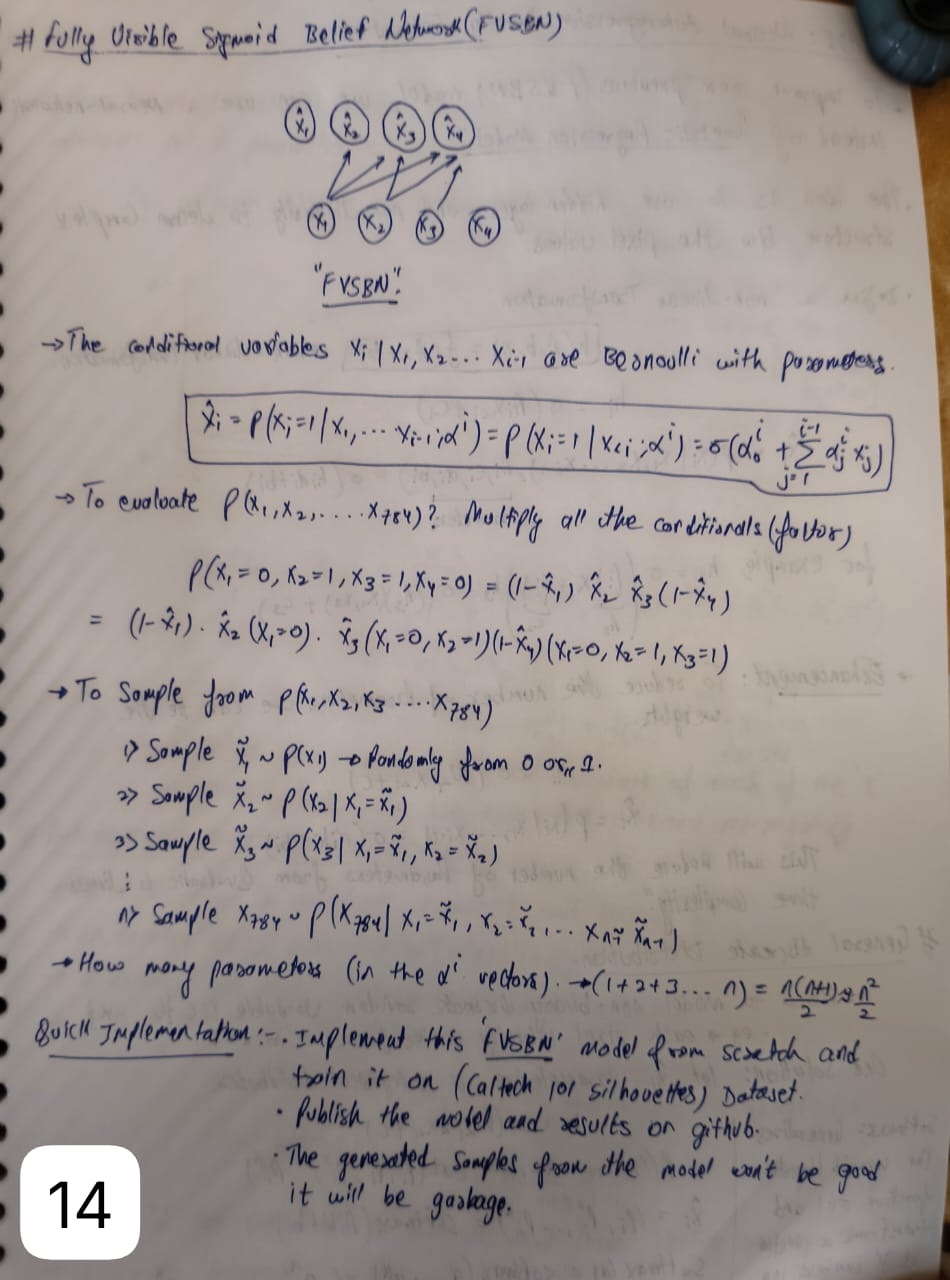

## Load the Dataset

In [1]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root="../data/caltech-101",
    transform=transform
)

loader = DataLoader(dataset, batch_size=8, shuffle=True)

print("Classes:", dataset.classes)
print("Total images:", len(dataset))

Classes: ['BACKGROUND_Google', 'Faces', 'Faces_easy', 'Leopards', 'Motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel', 'bass', 'beaver', 'binocular', 'bonsai', 'brain', 'brontosaurus', 'buddha', 'butterfly', 'camera', 'cannon', 'car_side', 'ceiling_fan', 'cellphone', 'chair', 'chandelier', 'cougar_body', 'cougar_face', 'crab', 'crayfish', 'crocodile', 'crocodile_head', 'cup', 'dalmatian', 'dollar_bill', 'dolphin', 'dragonfly', 'electric_guitar', 'elephant', 'emu', 'euphonium', 'ewer', 'ferry', 'flamingo', 'flamingo_head', 'garfield', 'gerenuk', 'gramophone', 'grand_piano', 'hawksbill', 'headphone', 'hedgehog', 'helicopter', 'ibis', 'inline_skate', 'joshua_tree', 'kangaroo', 'ketch', 'lamp', 'laptop', 'llama', 'lobster', 'lotus', 'mandolin', 'mayfly', 'menorah', 'metronome', 'minaret', 'nautilus', 'octopus', 'okapi', 'pagoda', 'panda', 'pigeon', 'pizza', 'platypus', 'pyramid', 'revolver', 'rhino', 'rooster', 'saxophone', 'schooner', 'scissors', 'scorpion', 'sea_horse', 'sn

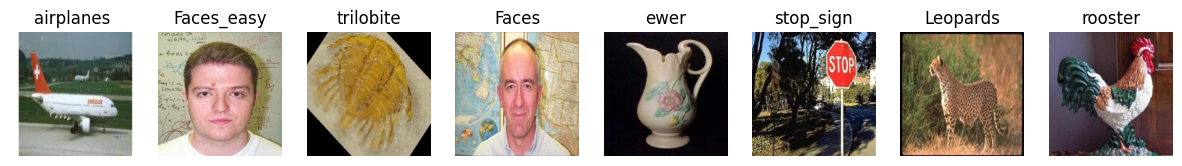

In [2]:
import matplotlib.pyplot as plt

images, labels = next(iter(loader))

fig, axes = plt.subplots(1, 8, figsize=(15,3))

for i in range(8):
    axes[i].imshow(images[i].permute(1,2,0))
    axes[i].set_title(dataset.classes[labels[i]])
    axes[i].axis("off")

plt.show()

### Converting them into GreyScale (To reduce number of Parameters of Model)

In [3]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # convert RGB → 1 channel
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root="../data/caltech-101",
    transform=transform
)

loader = DataLoader(dataset, batch_size=64, shuffle=True)

### visualize them into Bernoulli

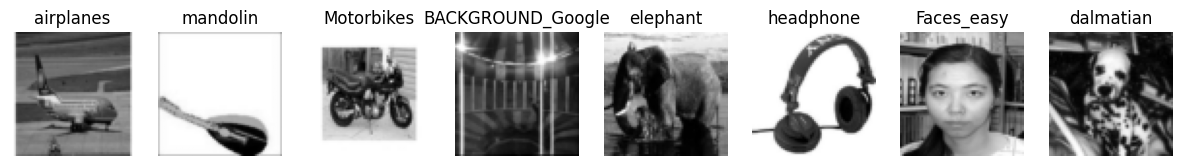

In [4]:
import matplotlib.pyplot as plt

images, labels = next(iter(loader))
images = images / 255.0

fig, axes = plt.subplots(1, 8, figsize=(15,3))

for i in range(8):

    axes[i].imshow(images[i].squeeze(), cmap='gray')  # remove channel dim
    axes[i].set_title(dataset.classes[labels[i]])
    axes[i].axis("off")

plt.show()

### This looks blurry because this is resized from 224 x 224 to 28 x 28 (to reduce number of parameters, because I'm using Logistic Regression and not CNN)

## Make the Model (FVSBN)

In [5]:
import torch.nn as nn
import torch
import torch.nn.functional as F
from tqdm import tqdm

In [6]:
class LinearLayer(nn.Module):
    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        self.weight = nn.Parameter(torch.rand(self.in_features, self.out_features))
        self.bias = nn.Parameter(torch.rand(self.out_features))

        nn.init.xavier_uniform_(self.weight)
        nn.init.zeros_(self.bias)
    
    def forward(self, x: torch.tensor):
        return x @ self.weight + self.bias

class LayerNorm(nn.Module):
    def __init__(self, in_features: int, eps: float = 0.001):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(in_features))
        self.shift = nn.Parameter(torch.zeros(in_features))
        self.eps = eps
    
    def forward(self, x: torch.tensor):
        x_mean = x.mean(dim = -1, keepdim = True)
        x_var = x.var(dim = - 1, keepdim = True, unbiased = False)
        x_norm = (x - x_mean / torch.sqrt(x_var + self.eps))
        return self.scale * x_norm + self.shift
    
class FVSBN(nn.Module):
    def __init__(self, in_features: int, hidden_dim: int, out_features: int):
        super().__init__()
        self.linear_layer_1 = LinearLayer(in_features, hidden_dim)
        self.linear_layer_2 = LinearLayer(hidden_dim, hidden_dim)
        self.linear_layer_3 = LinearLayer(hidden_dim, out_features)
        self.layer_norm_1 = LayerNorm(hidden_dim)
        self.layer_norm_2 = LayerNorm(hidden_dim)
    
    def forward(self, x: torch.tensor):
        h1 = self.linear_layer_1(x)
        h1 = self.layer_norm_1(h1)
        h1 = F.relu(h1)

        h2 = self.linear_layer_2(h1)
        h2 = self.layer_norm_2(h2)
        h2 = F.relu(h2)

        logits = self.linear_layer_3(h2)
        return logits

def train_fvsbn_model(model: FVSBN, loader: DataLoader, epochs: int, optimizer: torch.optim, device: torch.device):
    model.to(device)
    for epoch in tqdm(range(epochs), desc="Training", position=0):

        total_loss = 0

        batch_bar = tqdm(loader, desc=f"Epoch {epoch+1}", leave=False, position=1)

        for images, _ in batch_bar:

            x = images.view(images.size(0), -1)
            x = x.to(device)

            logits = model(x)

            loss = F.binary_cross_entropy_with_logits(logits, x)
            if torch.isnan(loss):
                print("NaN detected, stopping training")
                break

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()

            batch_bar.set_postfix(loss=loss.item())

        avg_loss = total_loss / len(loader)

        if epoch % 10 == 0:
            print(f"Epoch [{epoch}/{epochs}] | Avg Loss = {avg_loss:.4f}")

    return model

## Train this Model on the Dataset

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

## Making the Model with 21 million parameters

In [8]:
in_features = images[0].shape[-1] * images[0].shape[-1]
out_features = images[0].shape[-1] * images[0].shape[-1]
hidden_dim = 2048
fvsbn = FVSBN(in_features, hidden_dim, out_features)
lr = 0.01
optimizer = torch.optim.Adam(params = fvsbn.parameters(), lr = lr)
trained_fvsbn = train_fvsbn_model(
    model = fvsbn,
    loader = loader,
    epochs = 100,
    optimizer = optimizer,
    device = device
)

Training:   1%|          | 1/100 [00:13<21:50, 13.23s/it]

Epoch [0/100] | Avg Loss = 5.7630


Training:  11%|█         | 11/100 [02:20<19:29, 13.14s/it]

Epoch [10/100] | Avg Loss = 0.5650


Training:  21%|██        | 21/100 [04:34<17:34, 13.35s/it]

...

Training:  81%|████████  | 81/100 [18:11<04:15, 13.42s/it]

Epoch [80/100] | Avg Loss = 0.6886


Training:  91%|█████████ | 91/100 [20:26<02:01, 13.47s/it]

Epoch [90/100] | Avg Loss = 0.6885


Training: 100%|██████████| 100/100 [22:26<00:00, 13.46s/it]


## Save the Model

In [9]:
torch.save(trained_fvsbn.state_dict(), "../saved_models/fvsbn_03_grey_scale_64x64.pth")
print("Model saved successfully")

Model saved successfully


## Load the Model

In [10]:
import torch

# recreating the same architecture
in_features = 64 * 64
out_features = 64 * 64
hidden_dim = 2048
model = FVSBN(in_features, hidden_dim, out_features)

# loading the weights
model.load_state_dict(
    torch.load("../saved_models/fvsbn_03_grey_scale_64x64.pth", map_location="cpu")
)
model.eval()
print("Model loaded successfully")

Model loaded successfully


C:\Users\Himanshu Singh\AppData\Local\Temp\ipykernel_20648\2084807395.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("../saved_models/fvsbn_03_grey_scale_64

## Now sample from the Model

In [15]:
import torch

def sample_fvsbn_continuous(model, image_size=64, device="cpu"):

    model.eval()
    model.to(device)

    num_pixels = image_size * image_size

    # empty image
    x = torch.rand(1, num_pixels).to(device)
    print(x)

    with torch.no_grad():

        for i in range(num_pixels):

            logits = model(x)
            intensity = torch.sigmoid(logits)

            noise_std = 0.00008
            x[0,i] = torch.clamp(
                intensity[0,i] + noise_std * torch.randn(1).to(device),
                0, 1
            )

    return x

tensor([[0.3499, 0.6850, 0.9448,  ..., 0.3245, 0.8236, 0.4406]],
       device='cuda:0')


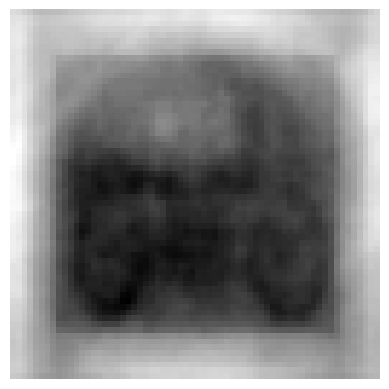

tensor([[0.4956, 0.3016, 0.0804,  ..., 0.6954, 0.1202, 0.2604]],
       device='cuda:0')


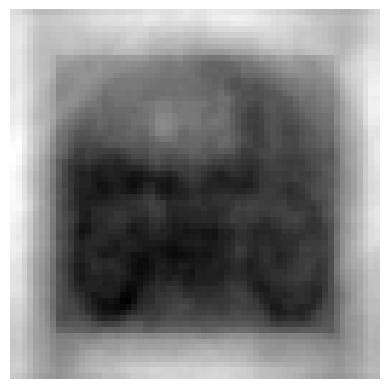

tensor([[0.7282, 0.9831, 0.5987,  ..., 0.9321, 0.4378, 0.5222]],
       device='cuda:0')


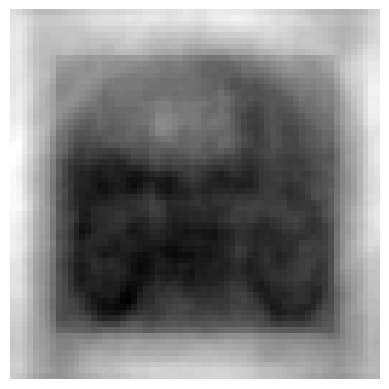

tensor([[0.8155, 0.1317, 0.1956,  ..., 0.3260, 0.1198, 0.0838]],
       device='cuda:0')


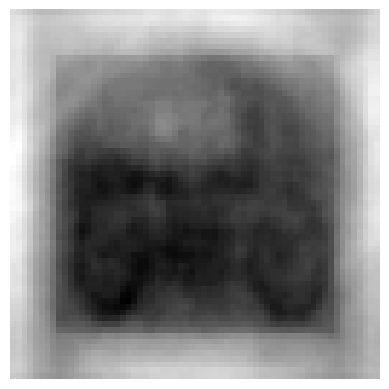

tensor([[0.1080, 0.6334, 0.1004,  ..., 0.5821, 0.5470, 0.6697]],
       device='cuda:0')


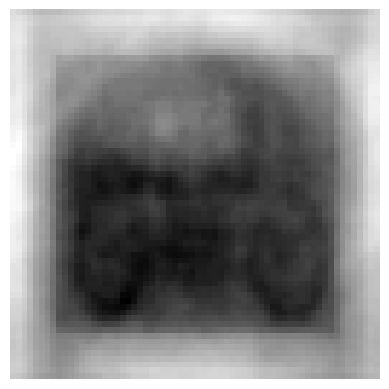

In [16]:
for i in range(5):

    sample = sample_fvsbn_continuous(trained_fvsbn, 64, device)

    img = sample.view(64,64).cpu()

    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.show()